In [1]:
"""
Fragment 1 — Data Loading
==========================
ResNet50 Mould/Fruit Multiclass Classification Pipeline

- Loads train data from shared augmented folder
- Loads validation data from val folder
- Test data not loaded here
- No augmentation performed — augmented folder already exists
- Uses ResNet50 preprocess_input instead of rescale
"""

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies\Mould Studies Multiclass"
AUG_DIR    = os.path.join(DATA_DIR, "augmented")   # shared augmented folder
VALID_DIR  = os.path.join(DATA_DIR, "val")

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# ── Safety Guards ─────────────────────────────────────────────────────────────

assert os.path.exists(AUG_DIR), \
    f"Augmented folder not found: {AUG_DIR}"
assert os.path.exists(VALID_DIR), \
    f"Validation folder not found: {VALID_DIR}"

# ── Step 1: Build Generators ──────────────────────────────────────────────────

def build_generators(aug_dir: str, valid_dir: str):
    """
    Builds train generator from shared augmented folder.
    Builds validation generator from val folder.
    Both use ResNet50 preprocess_input — ResNet50 expects
    inputs normalised using ImageNet channel-wise mean
    subtraction via its own preprocess_input function.
    This converts RGB to BGR and zero-centers each channel
    with respect to the ImageNet dataset.
    Test data is not loaded here.
    """

    train_datagen   = ImageDataGenerator(preprocessing_function=preprocess_input)
    train_generator = train_datagen.flow_from_directory(
        aug_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = True,
    )

    valid_datagen   = ImageDataGenerator(preprocessing_function=preprocess_input)
    valid_generator = valid_datagen.flow_from_directory(
        valid_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = False,
    )

    return train_generator, valid_generator

# ── Step 2: Run and Summarise ─────────────────────────────────────────────────

train_generator, valid_generator = build_generators(AUG_DIR, VALID_DIR)

CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("=" * 60)
print("  Fragment 1 — Data Generators Ready")
print("=" * 60)
print(f"  Architecture  : ResNet50")
print(f"  Train source  : augmented/   (shared, no new aug)")
print(f"  Valid source  : val/")
print(f"  Test source   : not loaded here")
print(f"  Preprocessing : ResNet50 preprocess_input")
print(f"                  (BGR conversion + ImageNet mean subtraction)")
print(f"  Train samples : {train_generator.samples}")
print(f"  Valid samples : {valid_generator.samples}")
print(f"  Classes ({NUM_CLASSES})  : {CLASS_NAMES}")
print(f"  Image size    : {IMG_SIZE}")
print(f"  Batch size    : {BATCH_SIZE}")
print("=" * 60)

print("\n  ✓ Fragment 1 complete. train_generator and valid_generator are ready.")
print("     Proceed to Fragment 2 — ResNet50 Model Building.\n")


Found 8833 images belonging to 11 classes.
Found 644 images belonging to 11 classes.
  Fragment 1 — Data Generators Ready
  Architecture  : ResNet50
  Train source  : augmented/   (shared, no new aug)
  Valid source  : val/
  Test source   : not loaded here
  Preprocessing : ResNet50 preprocess_input
                  (BGR conversion + ImageNet mean subtraction)
  Train samples : 8833
  Valid samples : 644
  Classes (11)  : ['Blackberry', 'Blueberry', 'Carrots', 'Cheese', 'Cream Cheese', 'Mixed Bread', 'Onion', 'Orange', 'Raspberry', 'Toast', 'Tomatoes']
  Image size    : (224, 224)
  Batch size    : 32

  ✓ Fragment 1 complete. train_generator and valid_generator are ready.
     Proceed to Fragment 2 — ResNet50 Model Building.



In [2]:
"""
Fragment 2 — ResNet50 Model Building with Transfer Learning
============================================================
- Loads ResNet50 with ImageNet weights
- Accepts learning rate, dropout rate and unfreeze depth as inputs
- Freezes base layers except last N unfrozen layers
- Adds custom classification head
- Compiled and ready for training in Fragment 3
"""

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.optimizers import Adam

# ── Configuration ─────────────────────────────────────────────────────────────

IMG_SIZE    = (224, 224)
IMG_SHAPE   = IMG_SIZE + (3,)
NUM_CLASSES = len(train_generator.class_indices)
CLASS_NAMES = list(train_generator.class_indices.keys())

# ── Default values ────────────────────────────────────────────────────────────

DEFAULT_LEARNING_RATE   = 1e-4
DEFAULT_DROPOUT_RATE    = 0.3
DEFAULT_UNFREEZE_LAYERS = 0
EPOCHS                  = 25

# ── Step 1: Model Builder ─────────────────────────────────────────────────────

def build_resnet50(learning_rate, dropout_rate, unfreeze_layers, epochs=EPOCHS):
    """
    Builds and compiles ResNet50 with a custom classification head.

    Parameters
    ----------
    learning_rate   : float — Adam optimizer learning rate
                              Recommended range : 1e-5 to 1e-3 (log scale)
                              ResNet50 is robust to a wider LR range
                              than EfficientNet but 1e-4 is a safe
                              starting point for transfer learning

    dropout_rate    : float — dropout applied in classification head
                              Recommended range : 0.2 to 0.5
                              ResNet50 uses residual connections which
                              provide some built-in regularisation so
                              moderate dropout is sufficient

    unfreeze_layers : int   — number of base layers unfrozen from the top
                              Recommended range : 0 to 15
                              ResNet50 has ~175 layers organised into
                              4 residual stages — unfreeze conservatively
                              to avoid overwriting useful residual features
                              0  = fully frozen, feature extraction only
                              5  = unfreeze last residual block
                              15 = unfreeze last two residual blocks

    epochs          : int   — number of training epochs
                              default : 25
    """

    # ── Load ResNet50 with ImageNet weights ──
    base_model = ResNet50(
        input_shape = IMG_SHAPE,
        include_top = False,        # remove ImageNet classifier
        weights     = "imagenet"    # load ImageNet weights
    )

    # ── Freeze all base layers first ──
    base_model.trainable = False

    # ── Unfreeze last N layers ──
    # BatchNorm layers are always kept frozen — ResNet50
    # uses BatchNorm after every convolution and unfreezing
    # them causes training instability especially with
    # small batch sizes
    if unfreeze_layers > 0:
        for layer in base_model.layers[-unfreeze_layers:]:
            if not isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = True

    # ── Classification head ──
    # ResNet50 outputs a 7x7 feature map — GlobalAveragePooling2D
    # reduces this to a compact feature vector before the head
    x      = base_model.output
    x      = GlobalAveragePooling2D(name="global_avg_pool")(x)
    x      = BatchNormalization(name="head_batch_norm")(x)
    x      = Dense(256, activation="relu", name="dense_256")(x)
    x      = Dropout(dropout_rate, name="dropout_1")(x)
    x      = Dense(128, activation="relu", name="dense_128")(x)
    x      = Dropout(dropout_rate / 2, name="dropout_2")(x)
    output = Dense(NUM_CLASSES, activation="softmax", name="output")(x)

    # ── Assemble model ──
    model = Model(inputs=base_model.input, outputs=output)

    # ── Compile ──
    model.compile(
        optimizer = Adam(learning_rate=learning_rate),
        loss      = "categorical_crossentropy",
        metrics   = ["accuracy"]
    )

    return model, base_model

# ── Step 2: Build default model and print summary ─────────────────────────────

model, base_model = build_resnet50(
    learning_rate   = DEFAULT_LEARNING_RATE,
    dropout_rate    = DEFAULT_DROPOUT_RATE,
    unfreeze_layers = DEFAULT_UNFREEZE_LAYERS
)

# ── Count parameters ──
total_params     = model.count_params()
trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen_params    = sum(tf.size(w).numpy() for w in model.non_trainable_weights)

# ── Count unfrozen base layers ──
unfrozen_base = sum(
    1 for l in model.layers
    if l.trainable
    and l.name not in
    ["global_avg_pool", "head_batch_norm",
     "dense_256", "dropout_1",
     "dense_128", "dropout_2", "output"]
)

print("=" * 60)
print("  Fragment 2 — ResNet50 Transfer Learning")
print("=" * 60)

print("\n  ── Inputs ──────────────────────────────────────────")
print(f"  Learning rate    : {DEFAULT_LEARNING_RATE}")
print(f"  Dropout rate     : {DEFAULT_DROPOUT_RATE}")
print(f"  Unfreeze layers  : {DEFAULT_UNFREEZE_LAYERS}")
print(f"  Epochs           : {EPOCHS}")

print("\n  ── Base Model ──────────────────────────────────────")
print(f"  Architecture     : ResNet50")
print(f"  Weights          : ImageNet ✓")
print(f"  Input shape      : {IMG_SHAPE}")
print(f"  Total base layers: {len(base_model.layers)}")
print(f"  Unfrozen layers  : {unfrozen_base}")

print("\n  ── Classification Head ─────────────────────────────")
print(f"  GlobalAveragePooling2D")
print(f"  BatchNormalization")
print(f"  Dense(256, relu)")
print(f"  Dropout({DEFAULT_DROPOUT_RATE})")
print(f"  Dense(128, relu)")
print(f"  Dropout({DEFAULT_DROPOUT_RATE / 2})")
print(f"  Dense({NUM_CLASSES}, softmax)  ← {NUM_CLASSES} classes")
print(f"  Classes          : {CLASS_NAMES}")

print("\n  ── Parameters ──────────────────────────────────────")
print(f"  Total params     : {total_params:,}")
print(f"  Trainable        : {trainable_params:,}")
print(f"  Frozen           : {frozen_params:,}")

print("\n  ── Recommended Search Space ────────────────────────")
print(f"  learning_rate    : 1e-5  → 1e-3  (log scale)")
print(f"  dropout_rate     : 0.2   → 0.5")
print(f"  unfreeze_layers  : 0     → 15")
print(f"  epochs           : {EPOCHS}")
print("=" * 60)

print("\n  ✓ Fragment 2 complete. build_resnet50() is ready.")
print("     Proceed to Fragment 3 — Callbacks & Training.\n")



  Fragment 2 — ResNet50 Transfer Learning

  ── Inputs ──────────────────────────────────────────
  Learning rate    : 0.0001
  Dropout rate     : 0.3
  Unfreeze layers  : 0
  Epochs           : 25

  ── Base Model ──────────────────────────────────────
  Architecture     : ResNet50
  Weights          : ImageNet ✓
  Input shape      : (224, 224, 3)
  Total base layers: 175
  Unfrozen layers  : 0

  ── Classification Head ─────────────────────────────
  GlobalAveragePooling2D
  BatchNormalization
  Dense(256, relu)
  Dropout(0.3)
  Dense(128, relu)
  Dropout(0.15)
  Dense(11, softmax)  ← 11 classes
  Classes          : ['Blackberry', 'Blueberry', 'Carrots', 'Cheese', 'Cream Cheese', 'Mixed Bread', 'Onion', 'Orange', 'Raspberry', 'Toast', 'Tomatoes']

  ── Parameters ──────────────────────────────────────
  Total params     : 24,154,763
  Trainable        : 562,955
  Frozen           : 23,591,808

  ── Recommended Search Space ────────────────────────
  learning_rate    : 1e-5  → 1e-3 

In [3]:
"""
Fragment 3 — Callbacks & Model Training
========================================
ResNet50 Mould/Fruit Multiclass Classification Pipeline

- Defines all callbacks:
    * ModelCheckpoint    — saves best model based on val_accuracy
    * EarlyStopping      — stops training if no improvement
    * ReduceLROnPlateau  — reduces LR when val_loss stalls
    * CSVLogger          — logs all metrics per epoch to CSV
- Trains ResNet50 using parameters defined in Fragment 2
- Validates on val set only
- Stores history for Fragment 4 evaluation:
    * Accuracy, Loss curves
    * Sensitivity, Specificity, Recall, F1, AUC/ROC
    * Confusion Matrix
"""

import os
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger,
)

# ── Configuration ─────────────────────────────────────────────────────────────

SAVE_DIR     = r"D:\Mold Studies\Models"
MODEL_NAME   = "resnet50_mould_best.keras"
CSV_LOG_NAME = "resnet50_training_log.csv"

os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(SAVE_DIR, MODEL_NAME)
CSV_PATH   = os.path.join(SAVE_DIR, CSV_LOG_NAME)

# ── Callback Parameters ───────────────────────────────────────────────────────

# EarlyStopping
ES_PATIENCE   = 10       # stop after N epochs with no val_accuracy improvement
ES_MIN_DELTA  = 1e-4     # minimum change to count as improvement

# ReduceLROnPlateau
RLROP_FACTOR    = 0.5    # multiply LR by this on plateau
RLROP_PATIENCE  = 5      # epochs with no improvement before reducing LR
RLROP_MIN_LR    = 1e-7   # LR floor
RLROP_MIN_DELTA = 1e-4   # minimum change to count as improvement

# ── Step 1: Define Callbacks ──────────────────────────────────────────────────

checkpoint = ModelCheckpoint(
    filepath          = MODEL_PATH,
    monitor           = "val_accuracy",
    save_best_only    = True,
    save_weights_only = False,
    save_format       = "keras",
    mode              = "max",
    verbose           = 1,
)

early_stopping = EarlyStopping(
    monitor              = "val_accuracy",
    patience             = ES_PATIENCE,
    min_delta            = ES_MIN_DELTA,
    mode                 = "max",
    restore_best_weights = True,
    verbose              = 1,
)

reduce_lr = ReduceLROnPlateau(
    monitor   = "val_loss",
    factor    = RLROP_FACTOR,
    patience  = RLROP_PATIENCE,
    min_lr    = RLROP_MIN_LR,
    min_delta = RLROP_MIN_DELTA,
    mode      = "min",
    verbose   = 1,
)

csv_logger = CSVLogger(
    filename  = CSV_PATH,
    separator = ",",
    append    = False,
)

callbacks = [checkpoint, early_stopping, reduce_lr, csv_logger]

print("=" * 60)
print("  Step 1 — Callbacks Configured")
print("=" * 60)
print(f"  ModelCheckpoint  : best val_accuracy → {MODEL_PATH}")
print(f"  EarlyStopping    : patience={ES_PATIENCE} epochs, "
      f"restores best weights")
print(f"  ReduceLROnPlateau: factor={RLROP_FACTOR} after "
      f"{RLROP_PATIENCE} stale epochs, floor={RLROP_MIN_LR}")
print(f"  CSVLogger        : epoch log → {CSV_PATH}")
print("=" * 60)

# ── Step 2: Training Configuration ───────────────────────────────────────────

print("\n" + "=" * 60)
print("  Step 2 — Training Configuration")
print("=" * 60)
print(f"  Architecture     : ResNet50")
print(f"  Train samples    : {train_generator.samples}")
print(f"  Valid samples    : {valid_generator.samples}")
print(f"  Test samples     : not touched here")
print(f"  Classes          : {NUM_CLASSES}")
print(f"  Epochs           : {EPOCHS}")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Learning rate    : {DEFAULT_LEARNING_RATE:.6f}")
print(f"  Dropout rate     : {DEFAULT_DROPOUT_RATE:.4f}")
print(f"  Unfreeze layers  : {DEFAULT_UNFREEZE_LAYERS}")
print("=" * 60 + "\n")

# ── Step 3: Build Final Model ─────────────────────────────────────────────────

model, base_model = build_resnet50(
    learning_rate   = DEFAULT_LEARNING_RATE,
    dropout_rate    = DEFAULT_DROPOUT_RATE,
    unfreeze_layers = DEFAULT_UNFREEZE_LAYERS,
    epochs          = EPOCHS,
)

# ── Step 4: Train ─────────────────────────────────────────────────────────────

history = model.fit(
    train_generator,
    epochs           = EPOCHS,
    validation_data  = valid_generator,
    callbacks        = callbacks,
    steps_per_epoch  = train_generator.samples  // BATCH_SIZE,
    validation_steps = valid_generator.samples  // BATCH_SIZE,
)

# ── Step 5: Force Save in .keras Format ──────────────────────────────────────

model.save(MODEL_PATH)
print(f"\n  ✓ Model explicitly saved in .keras format → {MODEL_PATH}")

# ── Step 6: Training Summary ──────────────────────────────────────────────────

best_val_acc  = max(history.history["val_accuracy"])
best_val_loss = min(history.history["val_loss"])
epochs_run    = len(history.history["accuracy"])
best_epoch    = history.history["val_accuracy"].index(best_val_acc) + 1

print("\n" + "=" * 60)
print("  Step 6 — Training Complete")
print("=" * 60)
print(f"  Architecture     : ResNet50")
print(f"  Epochs run       : {epochs_run} / {EPOCHS}")
print(f"  Best epoch       : {best_epoch}")
print(f"  Best val accuracy: {best_val_acc:.4f}  ({best_val_acc * 100:.2f}%)")
print(f"  Best val loss    : {best_val_loss:.4f}")
print(f"  Best model saved : {MODEL_PATH}")
print(f"  Training log     : {CSV_PATH}")
print("=" * 60)

print("\n  ── Metrics available for Fragment 4 evaluation ─────")
print("  ✓ Accuracy        — per epoch (train + val)")
print("  ✓ Loss            — per epoch (train + val)")
print("  ✓ Sensitivity     — will be computed from confusion matrix")
print("  ✓ Specificity     — will be computed from confusion matrix")
print("  ✓ Recall          — will be computed from confusion matrix")
print("  ✓ F1 Score        — will be computed from confusion matrix")
print("  ✓ AUC / ROC       — will be computed per class (one-vs-rest)")
print("  ✓ Confusion Matrix — full 11-class matrix")
print("=" * 60)

print("\n  ✓ Fragment 3 complete. history and model are ready.")
print("     Proceed to Fragment 3b — Multi-Run Training.\n")

  Step 1 — Callbacks Configured
  ModelCheckpoint  : best val_accuracy → D:\Mold Studies\Models\resnet50_mould_best.keras
  EarlyStopping    : patience=10 epochs, restores best weights
  ReduceLROnPlateau: factor=0.5 after 5 stale epochs, floor=1e-07
  CSVLogger        : epoch log → D:\Mold Studies\Models\resnet50_training_log.csv

  Step 2 — Training Configuration
  Architecture     : ResNet50
  Train samples    : 8833
  Valid samples    : 644
  Test samples     : not touched here
  Classes          : 11
  Epochs           : 25
  Batch size       : 32
  Learning rate    : 0.000100
  Dropout rate     : 0.3000
  Unfreeze layers  : 0

Epoch 1/25


276/276 [==============================] - ETA: 0s - loss: 0.5066 - accuracy: 0.8534
Epoch 1: val_accuracy improved from -inf to 0.97969, saving model to D:\Mold Studies\Models\resnet50_mould_best.keras
276/276 [==============================] - 203s 730ms/step - loss: 0.5066 - accuracy: 0.8534 - val_loss: 0.0707 - val_accuracy: 0.9797 - lr: 1.

In [4]:
"""
Fragment 3b — Multi-Run Training (ResNet50)
============================================
ResNet50 Mould/Fruit Multiclass Classification Pipeline

Runs 4 additional independent training loops (Runs 2–5).
Run 1 was completed in Fragment 3 and its model is already saved.
Each run starts from fresh ImageNet weights with randomly
reinitialised classification head.

OUTPUT: 5 models saved to disk for statistical analysis
    resnet50_run1_best.keras   (copied from Fragment 3)
    resnet50_run2_best.keras
    resnet50_run3_best.keras
    resnet50_run4_best.keras
    resnet50_run5_best.keras

DATA BOUNDARIES — unchanged from Fragment 3:
    Training   : train_generator  (augmented folder)
    Validation : valid_generator  (val folder)
    Test       : NOT TOUCHED — Fragment 4 only
"""

import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger,
)

# ── Configuration ─────────────────────────────────────────────────────────────

SAVE_DIR   = r"D:\Mold Studies\Models"
TOTAL_RUNS = 5

os.makedirs(SAVE_DIR, exist_ok=True)

# ── Step 1: Copy Fragment 3 model → Run 1 ────────────────────────────────────

src = os.path.join(SAVE_DIR, "resnet50_mould_best.keras")
dst = os.path.join(SAVE_DIR, "resnet50_run1_best.keras")

if os.path.exists(src) and not os.path.exists(dst):
    shutil.copy2(src, dst)
    print(f"  Copied  : resnet50_mould_best.keras → resnet50_run1_best.keras")
elif os.path.exists(dst):
    print(f"  Already exists : resnet50_run1_best.keras — skipping copy")
else:
    print(f"  WARNING : resnet50_mould_best.keras not found")
    print(f"            Ensure Fragment 3 completed successfully before continuing")

# ── Step 2: Collect Run 1 results from Fragment 3 ────────────────────────────

all_run_results = [
    {
        "run"          : 1,
        "best_val_acc" : best_val_acc,
        "best_val_loss": best_val_loss,
        "best_epoch"   : best_epoch,
        "checkpoint"   : "resnet50_run1_best.keras"
    }
]

print(f"\n  Run 1 loaded from Fragment 3")
print(f"    Architecture      : ResNet50")
print(f"    Best val accuracy : {best_val_acc:.4f}")
print(f"    Best val loss     : {best_val_loss:.4f}")
print(f"    Best epoch        : {best_epoch}")

# ── Step 3: Runs 2–5 ──────────────────────────────────────────────────────────

print(f"\n{'='*60}")
print(f"  MULTI-RUN TRAINING — Runs 2 to {TOTAL_RUNS}")
print(f"  Architecture : ResNet50")
print(f"  Each run     : fresh ImageNet weights, random head init")
print(f"  Epochs       : {EPOCHS}")
print(f"  LR           : {DEFAULT_LEARNING_RATE}")
print(f"  Dropout      : {DEFAULT_DROPOUT_RATE}")
print(f"  Unfreeze     : {DEFAULT_UNFREEZE_LAYERS} layers")
print(f"{'='*60}")

for run_idx in range(2, TOTAL_RUNS + 1):

    print(f"\n{'='*60}")
    print(f"  RUN {run_idx} / {TOTAL_RUNS}  —  ResNet50")
    print(f"{'='*60}\n")

    ckpt_path = os.path.join(SAVE_DIR, f"resnet50_run{run_idx}_best.keras")
    csv_path  = os.path.join(SAVE_DIR, f"resnet50_run{run_idx}_log.csv")

    # ── Fresh model — new random head, ImageNet backbone ──────────────────────
    run_model, _ = build_resnet50(
        learning_rate   = DEFAULT_LEARNING_RATE,
        dropout_rate    = DEFAULT_DROPOUT_RATE,
        unfreeze_layers = DEFAULT_UNFREEZE_LAYERS,
        epochs          = EPOCHS,
    )

    # ── Run-specific callbacks ─────────────────────────────────────────────────
    run_callbacks = [
        ModelCheckpoint(
            filepath          = ckpt_path,
            monitor           = "val_accuracy",
            save_best_only    = True,
            save_weights_only = False,
            save_format       = "keras",
            mode              = "max",
            verbose           = 1,
        ),
        EarlyStopping(
            monitor              = "val_accuracy",
            patience             = ES_PATIENCE,
            min_delta            = ES_MIN_DELTA,
            mode                 = "max",
            restore_best_weights = True,
            verbose              = 1,
        ),
        ReduceLROnPlateau(
            monitor   = "val_loss",
            factor    = RLROP_FACTOR,
            patience  = RLROP_PATIENCE,
            min_lr    = RLROP_MIN_LR,
            min_delta = RLROP_MIN_DELTA,
            mode      = "min",
            verbose   = 1,
        ),
        CSVLogger(
            filename  = csv_path,
            separator = ",",
            append    = False,
        ),
    ]

    # ── Train ──────────────────────────────────────────────────────────────────
    run_history = run_model.fit(
        train_generator,
        validation_data  = valid_generator,
        epochs           = EPOCHS,
        callbacks        = run_callbacks,
        steps_per_epoch  = train_generator.samples // BATCH_SIZE,
        validation_steps = valid_generator.samples // BATCH_SIZE,
    )

    # ── Extract best metrics ───────────────────────────────────────────────────
    run_best_val_acc  = max(run_history.history["val_accuracy"])
    run_best_val_loss = min(run_history.history["val_loss"])
    run_best_epoch    = run_history.history["val_accuracy"].index(run_best_val_acc) + 1
    run_epochs_run    = len(run_history.history["accuracy"])

    # ── Force save in .keras format ───────────────────────────────────────────
    run_model.save(ckpt_path)

    all_run_results.append({
        "run"          : run_idx,
        "best_val_acc" : run_best_val_acc,
        "best_val_loss": run_best_val_loss,
        "best_epoch"   : run_best_epoch,
        "checkpoint"   : f"resnet50_run{run_idx}_best.keras"
    })

    print(f"\n  Run {run_idx} complete")
    print(f"    Epochs run        : {run_epochs_run} / {EPOCHS}")
    print(f"    Best epoch        : {run_best_epoch}")
    print(f"    Best val accuracy : {run_best_val_acc:.4f}")
    print(f"    Best val loss     : {run_best_val_loss:.4f}")
    print(f"    Saved to          : {ckpt_path}")

# ── Step 4: Summary across all 5 runs ────────────────────────────────────────

val_accs   = [r["best_val_acc"]  for r in all_run_results]
val_losses = [r["best_val_loss"] for r in all_run_results]

print(f"\n{'='*60}")
print(f"  ALL RUNS COMPLETE — ResNet50 Summary")
print(f"{'='*60}")
print(f"  {'Run':<6} {'Val Acc':>10} {'Val Loss':>10} "
      f"{'Best Epoch':>12} {'Checkpoint'}")
print(f"  {'─'*70}")

for r in all_run_results:
    print(f"  {r['run']:<6} {r['best_val_acc']:>10.4f} "
          f"{r['best_val_loss']:>10.4f} {r['best_epoch']:>12} "
          f"{r['checkpoint']}")

best_run = max(all_run_results, key=lambda x: x["best_val_acc"])

print(f"\n  {'─'*60}")
print(f"  Mean val accuracy  : {np.mean(val_accs):.4f}")
print(f"  Std  val accuracy  : {np.std(val_accs):.4f}")
print(f"  Mean val loss      : {np.mean(val_losses):.4f}")
print(f"  Std  val loss      : {np.std(val_losses):.4f}")
print(f"\n  Best single run    : Run {best_run['run']} "
      f"— Val Acc {best_run['best_val_acc']:.4f}")
print(f"{'='*60}")

# ── Step 5: Expose checkpoint list for Fragment 4 ────────────────────────────

ensemble_checkpoints = [
    os.path.join(SAVE_DIR, r["checkpoint"]) for r in all_run_results
]

resnet50_all_run_results = all_run_results

print(f"\n  ✓ Fragment 3b complete.")
print(f"  ensemble_checkpoints = {ensemble_checkpoints}")
print(f"\n     Proceed to Fragment 4 — Evaluation & Metrics.\n")

  Copied  : resnet50_mould_best.keras → resnet50_run1_best.keras

  Run 1 loaded from Fragment 3
    Architecture      : ResNet50
    Best val accuracy : 1.0000
    Best val loss     : 0.0020
    Best epoch        : 10

  MULTI-RUN TRAINING — Runs 2 to 5
  Architecture : ResNet50
  Each run     : fresh ImageNet weights, random head init
  Epochs       : 25
  LR           : 0.0001
  Dropout      : 0.3
  Unfreeze     : 0 layers

  RUN 2 / 5  —  ResNet50

Epoch 1/25
276/276 [==============================] - ETA: 0s - loss: 0.4611 - accuracy: 0.8691
Epoch 1: val_accuracy improved from -inf to 0.98281, saving model to D:\Mold Studies\Models\resnet50_run2_best.keras
276/276 [==============================] - 145s 521ms/step - loss: 0.4611 - accuracy: 0.8691 - val_loss: 0.0673 - val_accuracy: 0.9828 - lr: 1.0000e-04
Epoch 2/25
276/276 [==============================] - ETA: 0s - loss: 0.0728 - accuracy: 0.9823
Epoch 2: val_accuracy improved from 0.98281 to 0.98750, saving model to D:\Mold St

Found 658 images belonging to 11 classes.
  Step 1 — Test Generator Ready
  Architecture  : ResNet50
  Preprocessing : preprocess_input
  Test samples  : 658
  Classes       : ['Blackberry', 'Blueberry', 'Carrots', 'Cheese', 'Cream Cheese', 'Mixed Bread', 'Onion', 'Orange', 'Raspberry', 'Toast', 'Tomatoes']
  Source        : D:\Mold Studies\Mould Studies Multiclass\test

  Evaluating ResNet50 Run 1 / 5
  Checkpoint : D:\Mold Studies\Models\resnet50_run1_best.keras
21/21 [==============================] - 10s 442ms/step

  Architecture : ResNet50
  Run          : 1
  Accuracy     : 0.9954
  Precision    : 0.9976
  Recall       : 0.9967
  Specificity  : 0.9995
  F1 Score     : 0.9971
  Mean AUC     : 1.0000


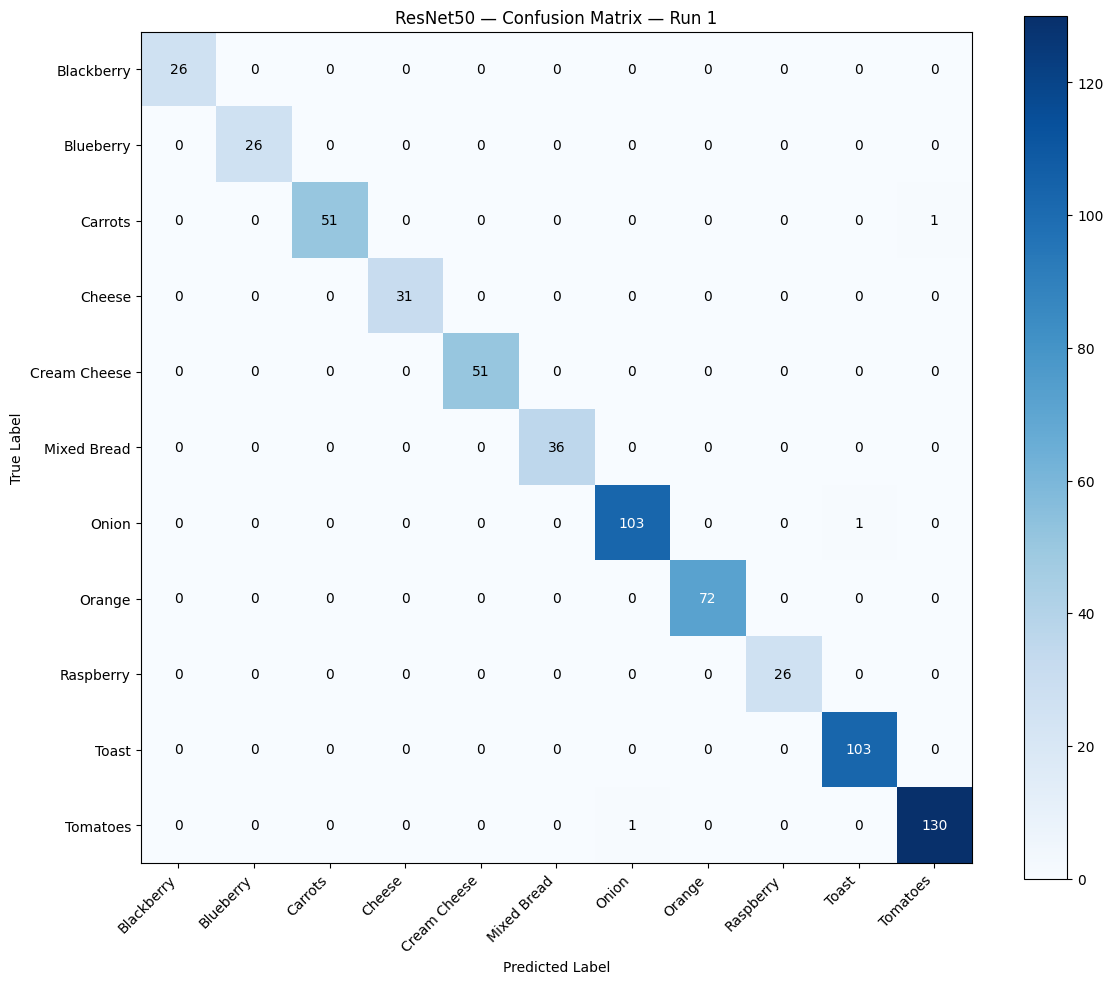

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_confusion_matrix_run1.png


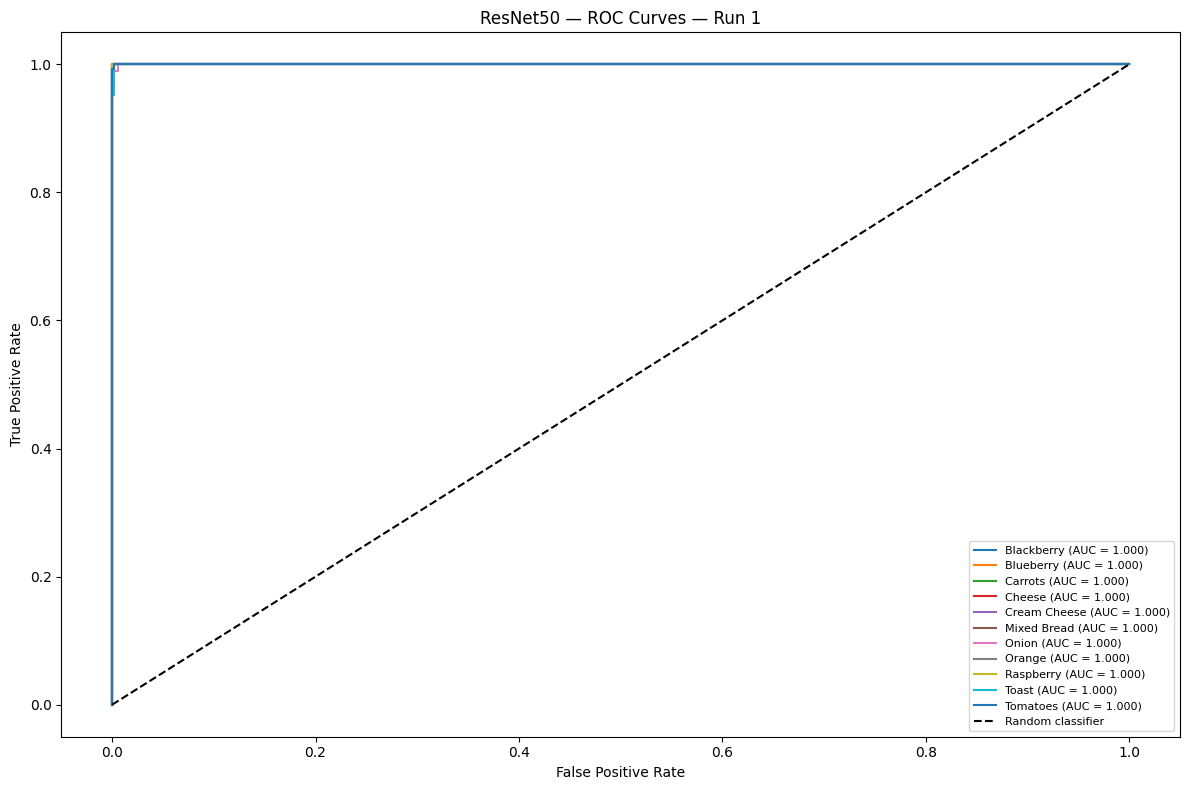

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_roc_curves_run1.png


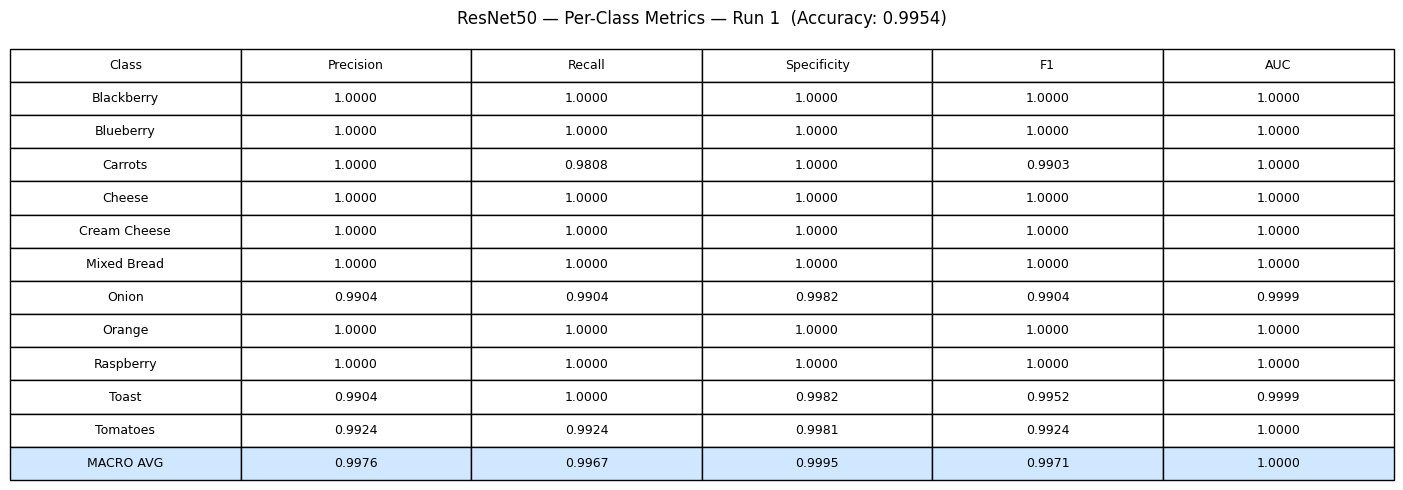

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_metrics_table_run1.png
  ⚠️  CSV log not found for Run 1: D:\Mold Studies\Models\resnet50_run1_log.csv

  Evaluating ResNet50 Run 2 / 5
  Checkpoint : D:\Mold Studies\Models\resnet50_run2_best.keras
21/21 [==============================] - 10s 429ms/step

  Architecture : ResNet50
  Run          : 2
  Accuracy     : 0.9939
  Precision    : 0.9967
  Recall       : 0.9942
  Specificity  : 0.9993
  F1 Score     : 0.9954
  Mean AUC     : 1.0000


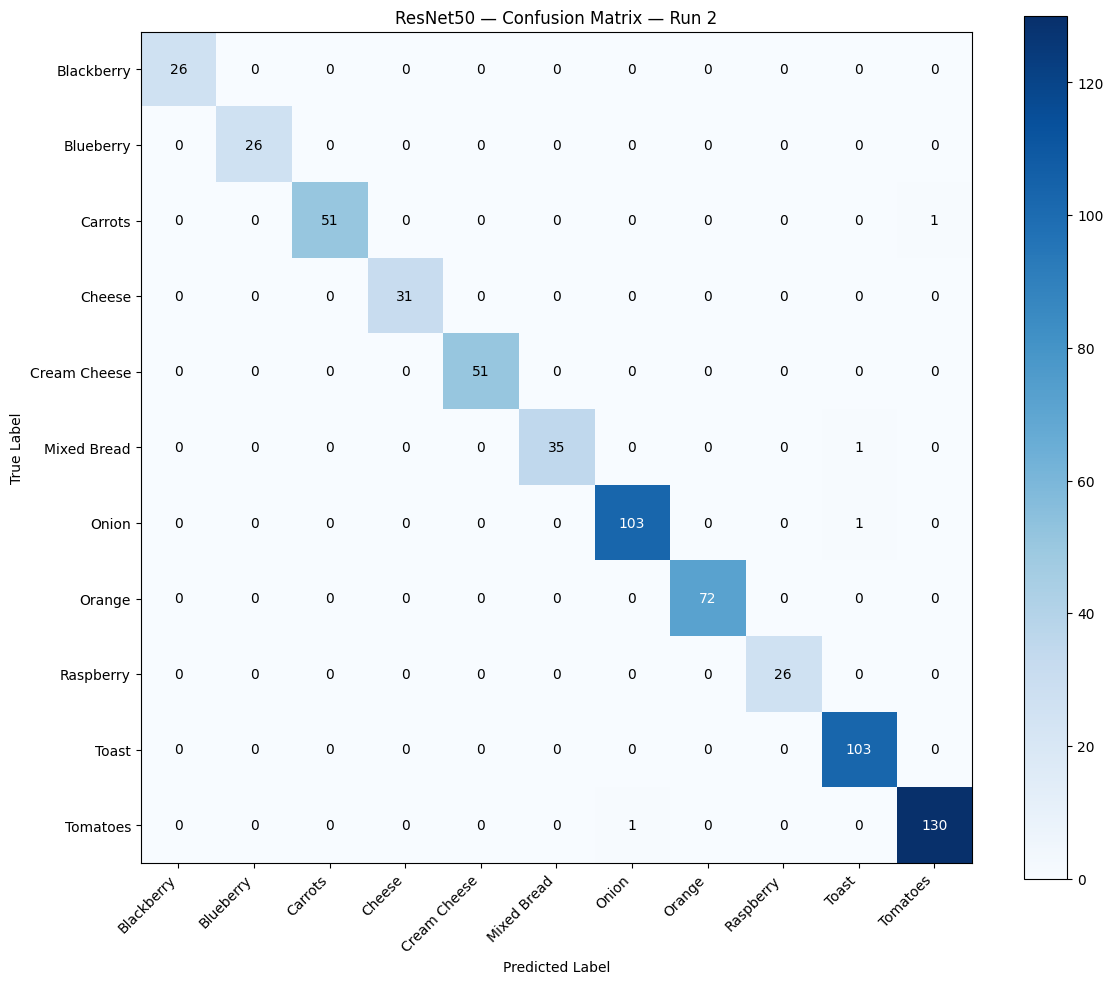

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_confusion_matrix_run2.png


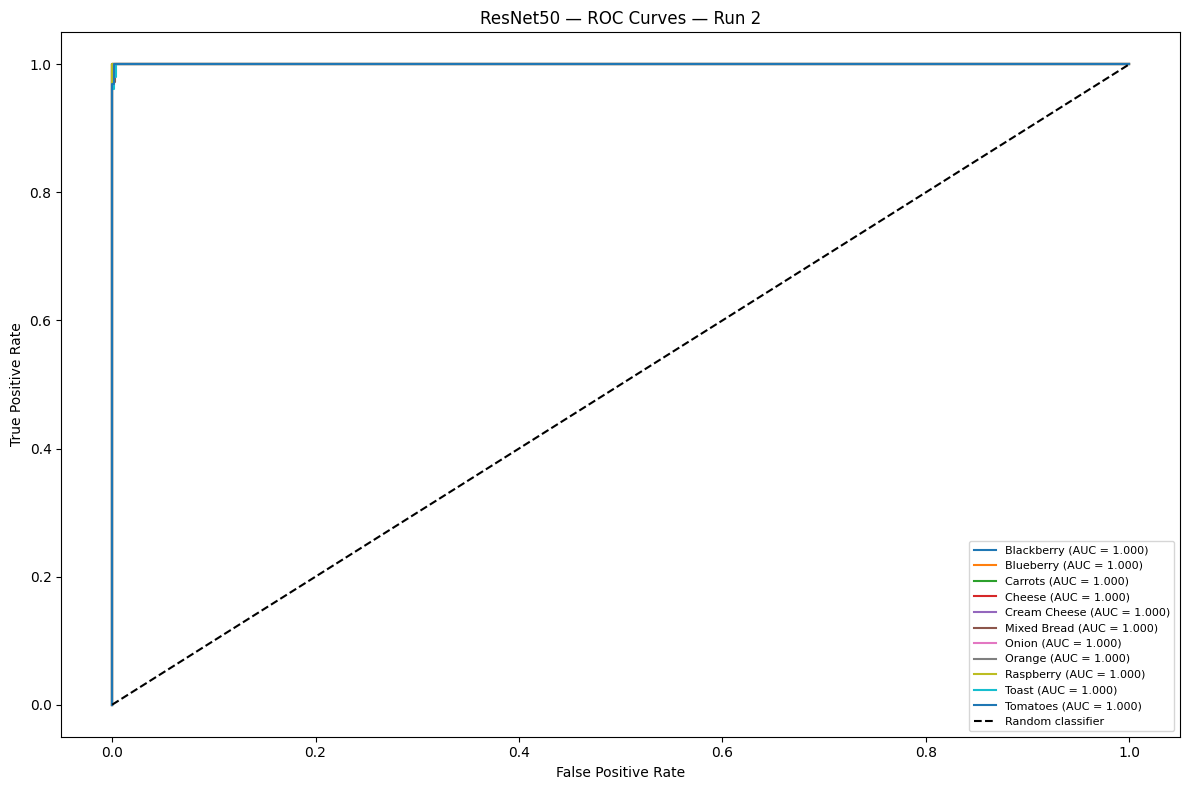

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_roc_curves_run2.png


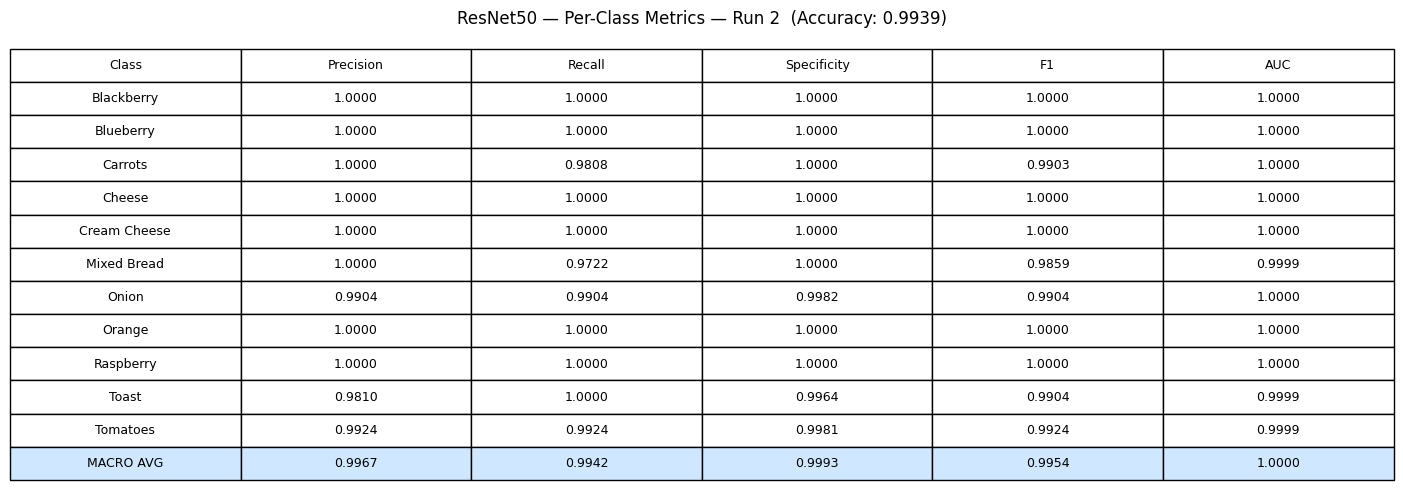

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_metrics_table_run2.png


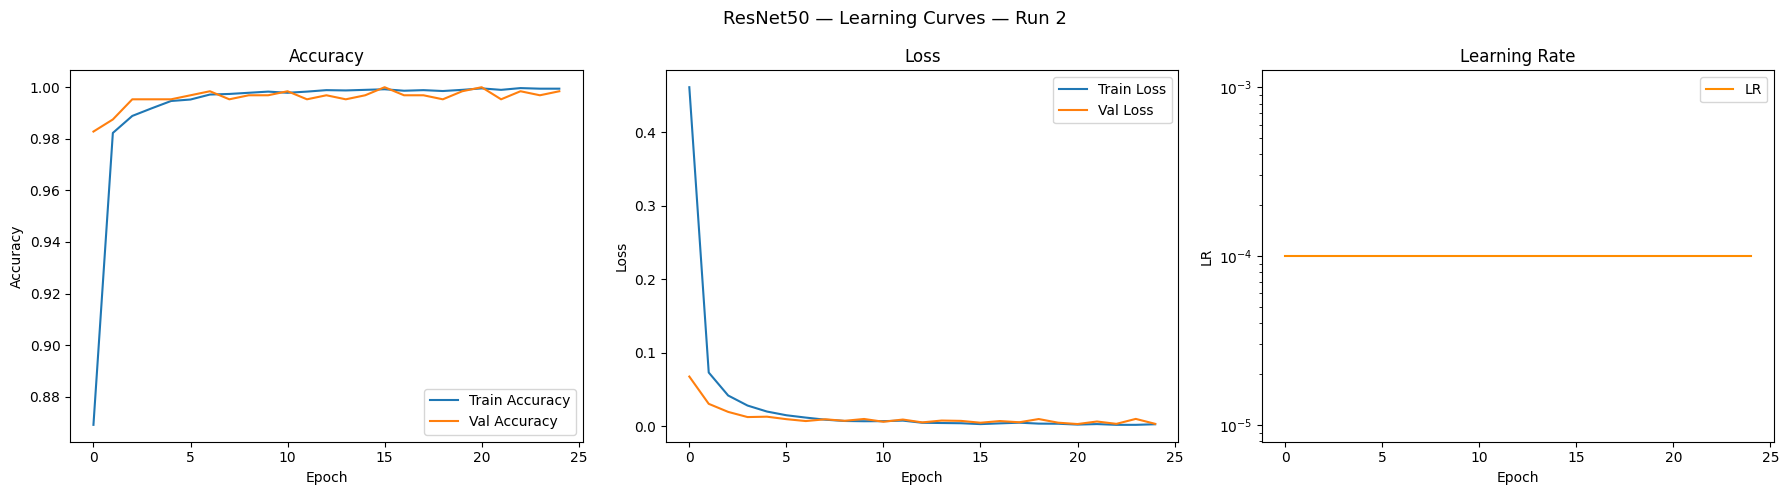

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_learning_curves_run2.png

  Evaluating ResNet50 Run 3 / 5
  Checkpoint : D:\Mold Studies\Models\resnet50_run3_best.keras
21/21 [==============================] - 9s 425ms/step

  Architecture : ResNet50
  Run          : 3
  Accuracy     : 0.9924
  Precision    : 0.9928
  Recall       : 0.9949
  Specificity  : 0.9992
  F1 Score     : 0.9938
  Mean AUC     : 1.0000


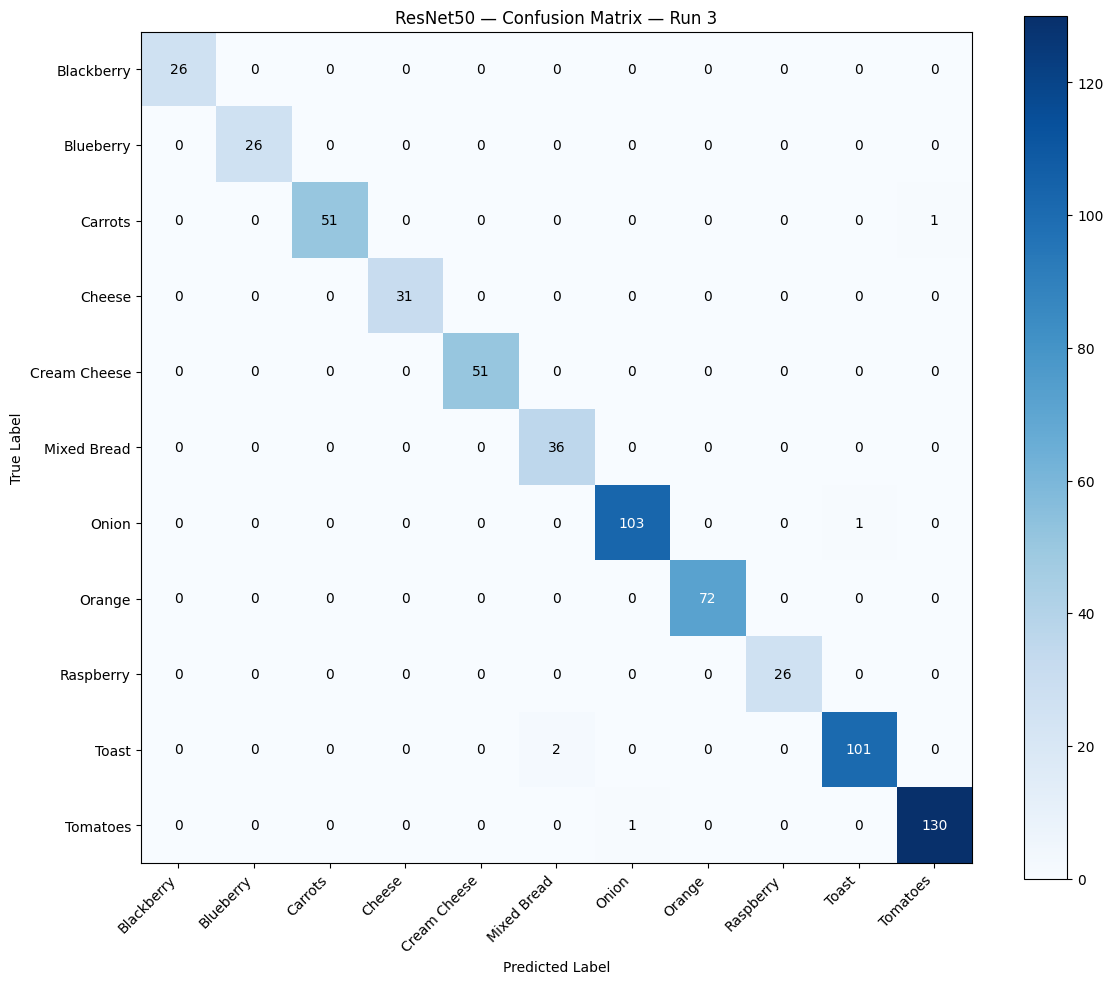

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_confusion_matrix_run3.png


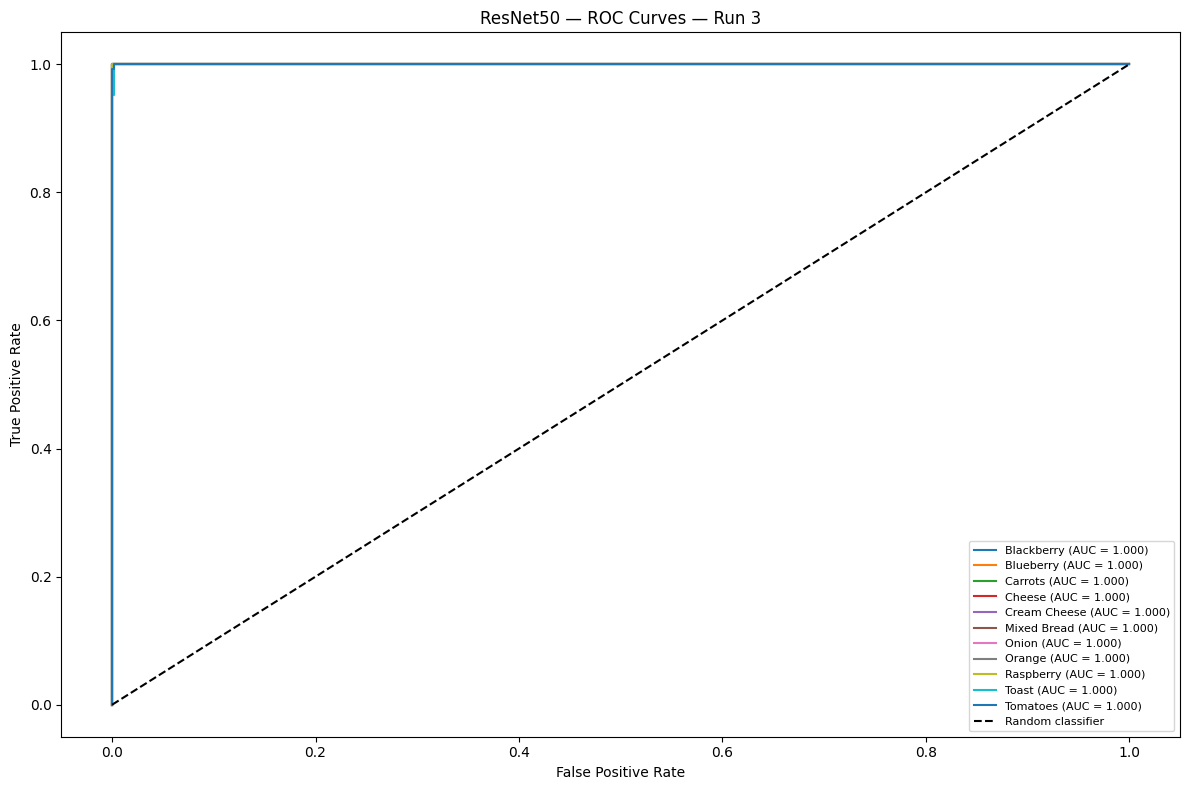

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_roc_curves_run3.png


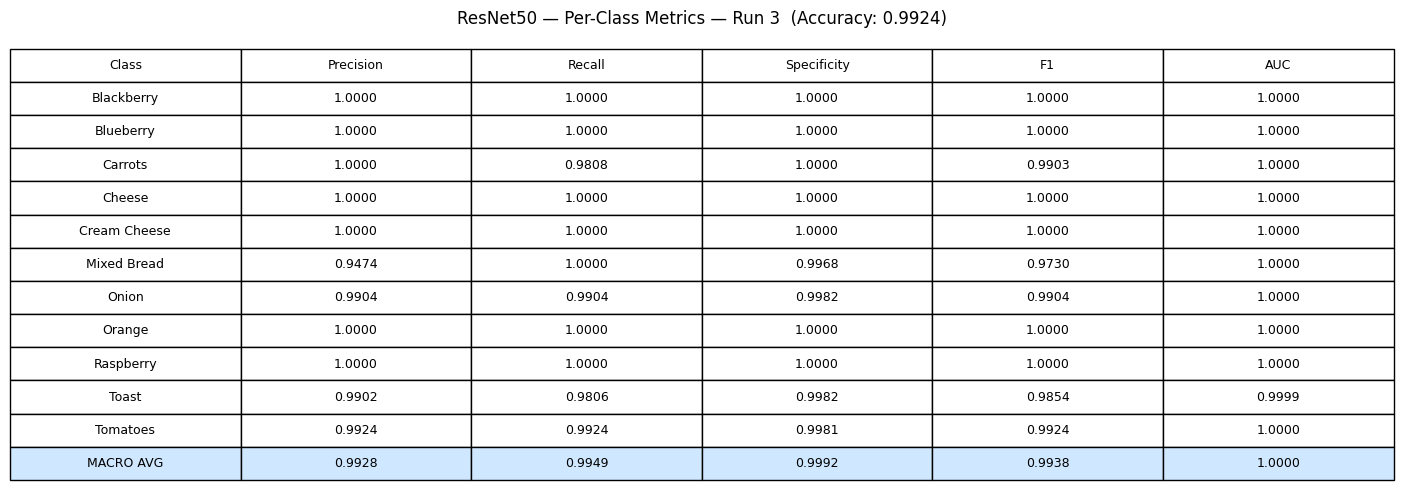

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_metrics_table_run3.png


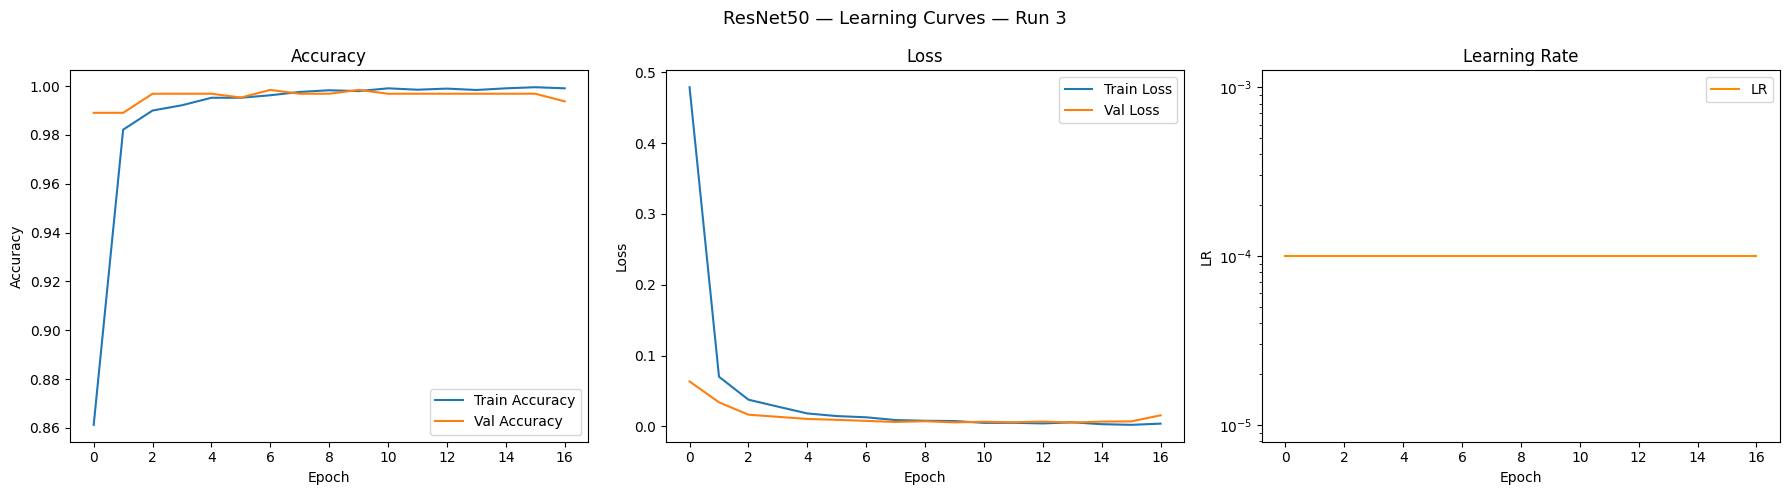

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_learning_curves_run3.png

  Evaluating ResNet50 Run 4 / 5
  Checkpoint : D:\Mold Studies\Models\resnet50_run4_best.keras
21/21 [==============================] - 10s 440ms/step

  Architecture : ResNet50
  Run          : 4
  Accuracy     : 0.9924
  Precision    : 0.9915
  Recall       : 0.9943
  Specificity  : 0.9992
  F1 Score     : 0.9929
  Mean AUC     : 1.0000


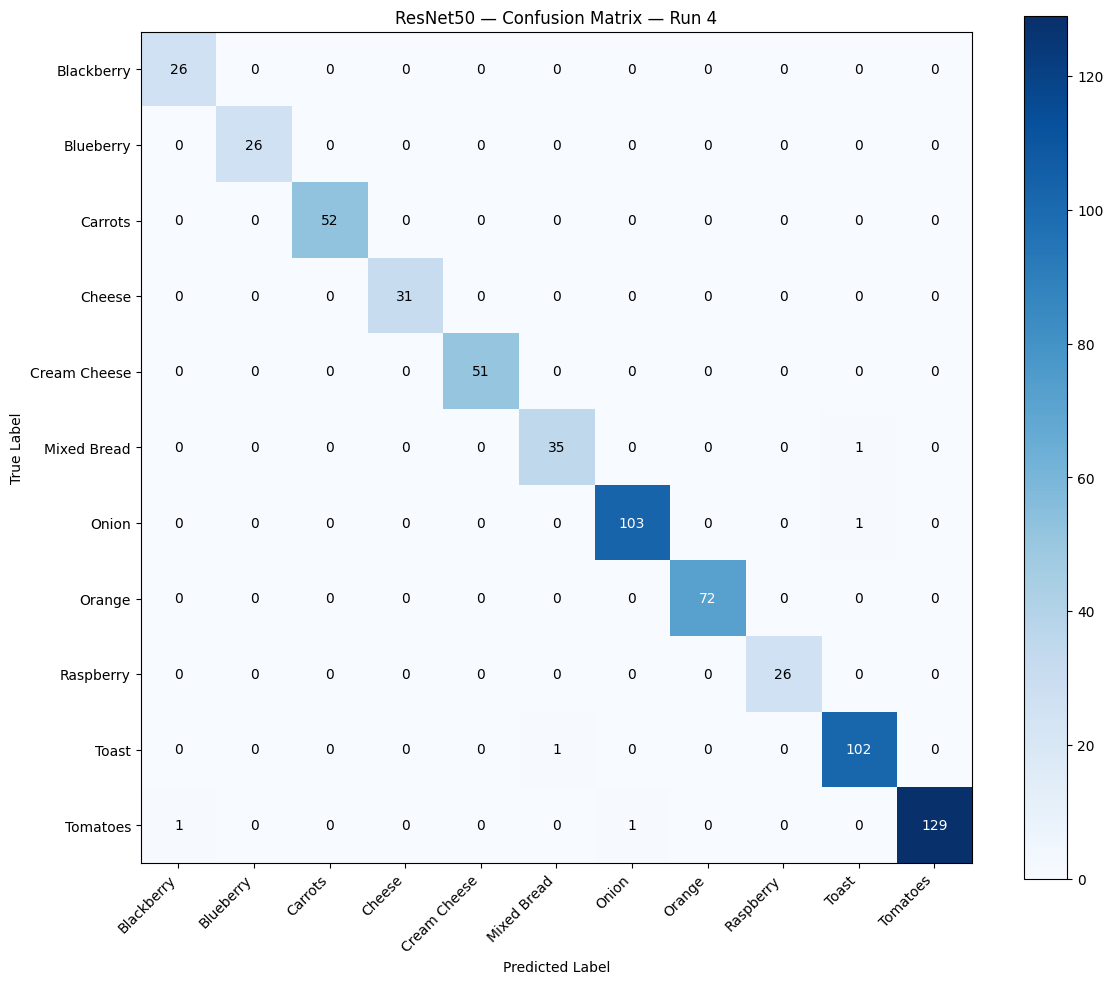

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_confusion_matrix_run4.png


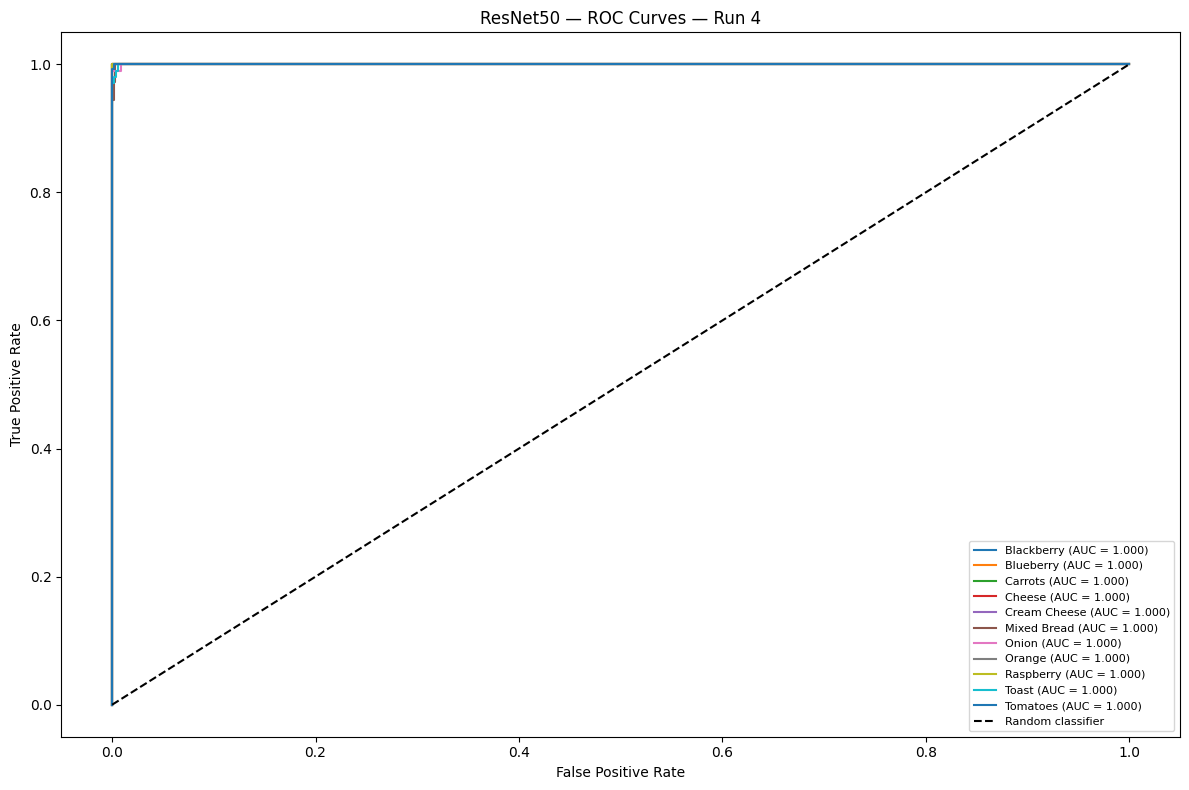

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_roc_curves_run4.png


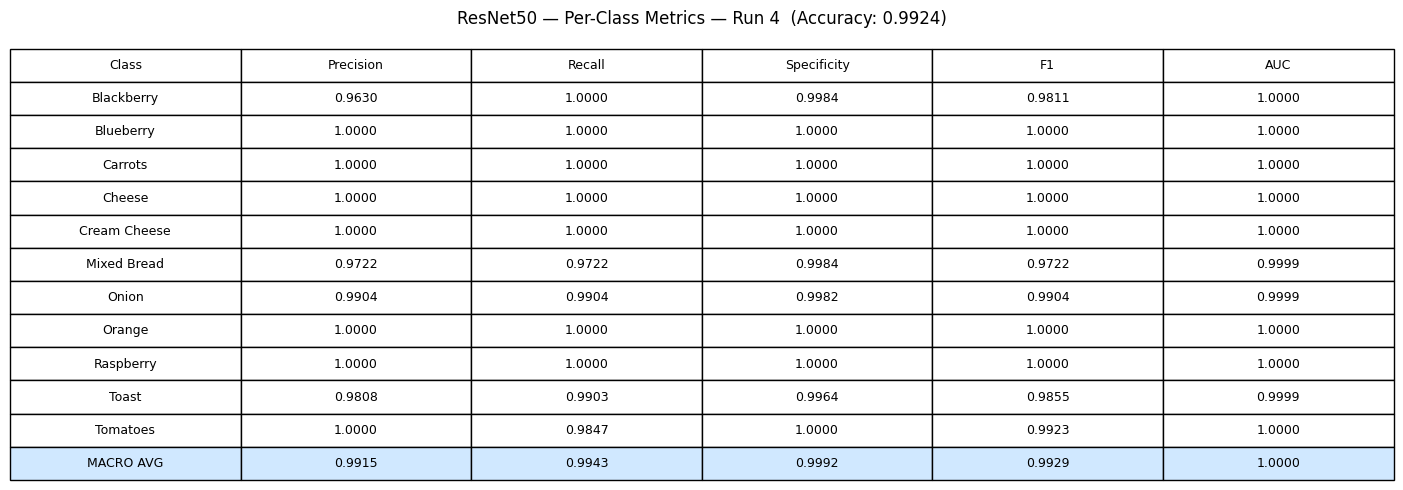

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_metrics_table_run4.png


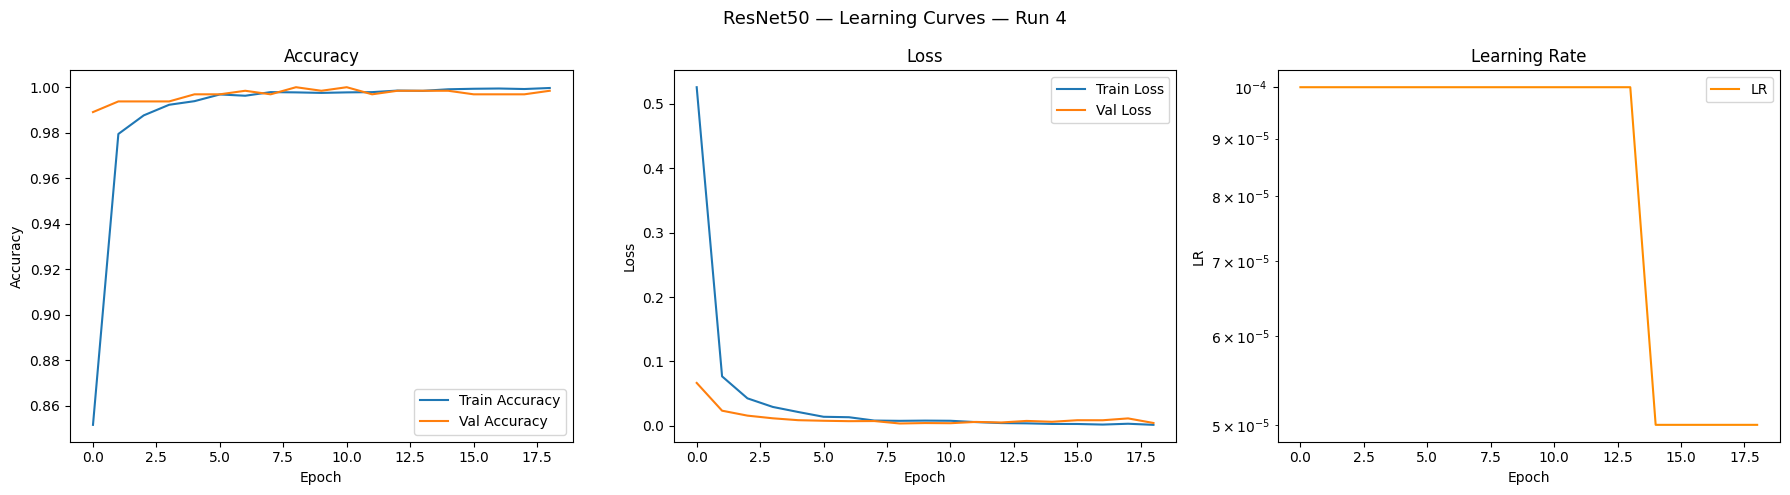

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_learning_curves_run4.png

  Evaluating ResNet50 Run 5 / 5
  Checkpoint : D:\Mold Studies\Models\resnet50_run5_best.keras
21/21 [==============================] - 10s 434ms/step

  Architecture : ResNet50
  Run          : 5
  Accuracy     : 0.9924
  Precision    : 0.9928
  Recall       : 0.9949
  Specificity  : 0.9992
  F1 Score     : 0.9938
  Mean AUC     : 1.0000


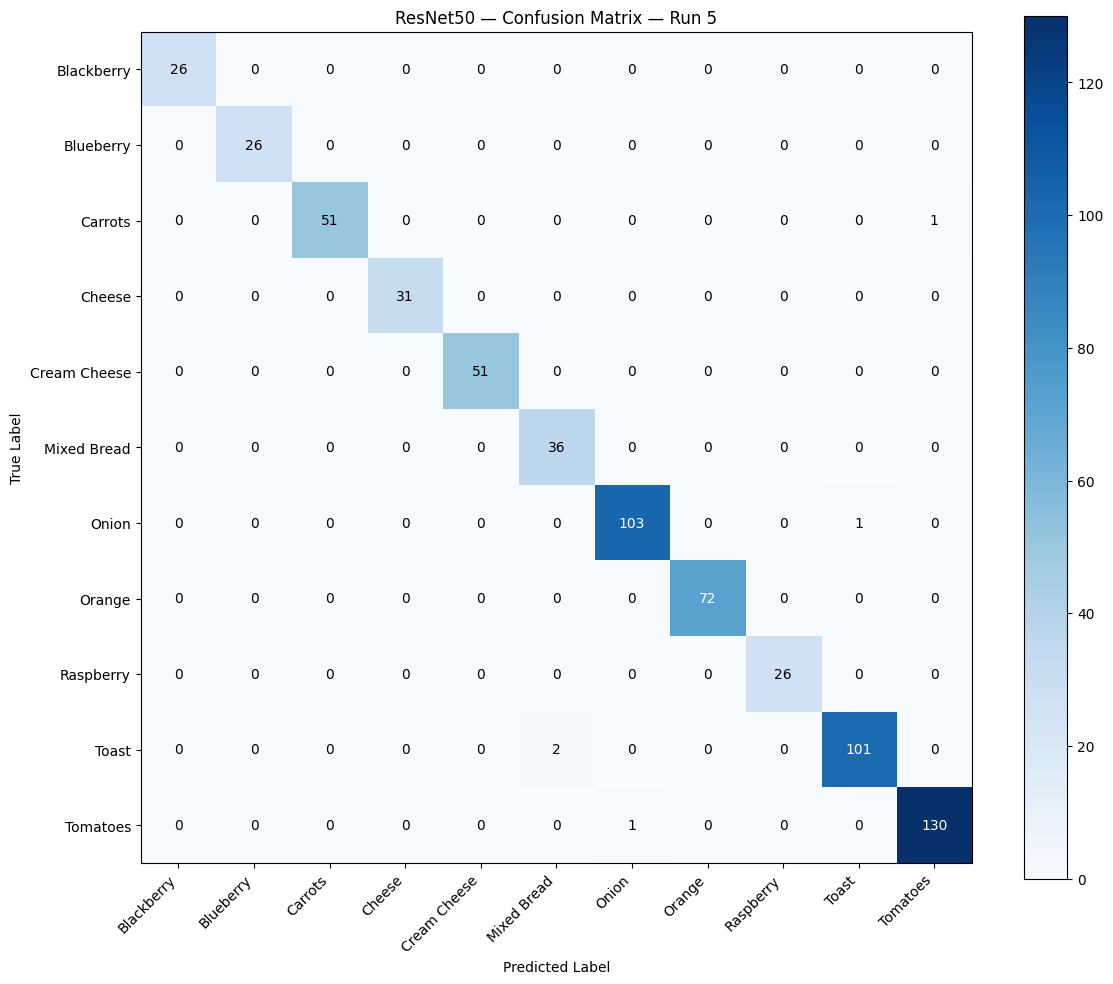

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_confusion_matrix_run5.png


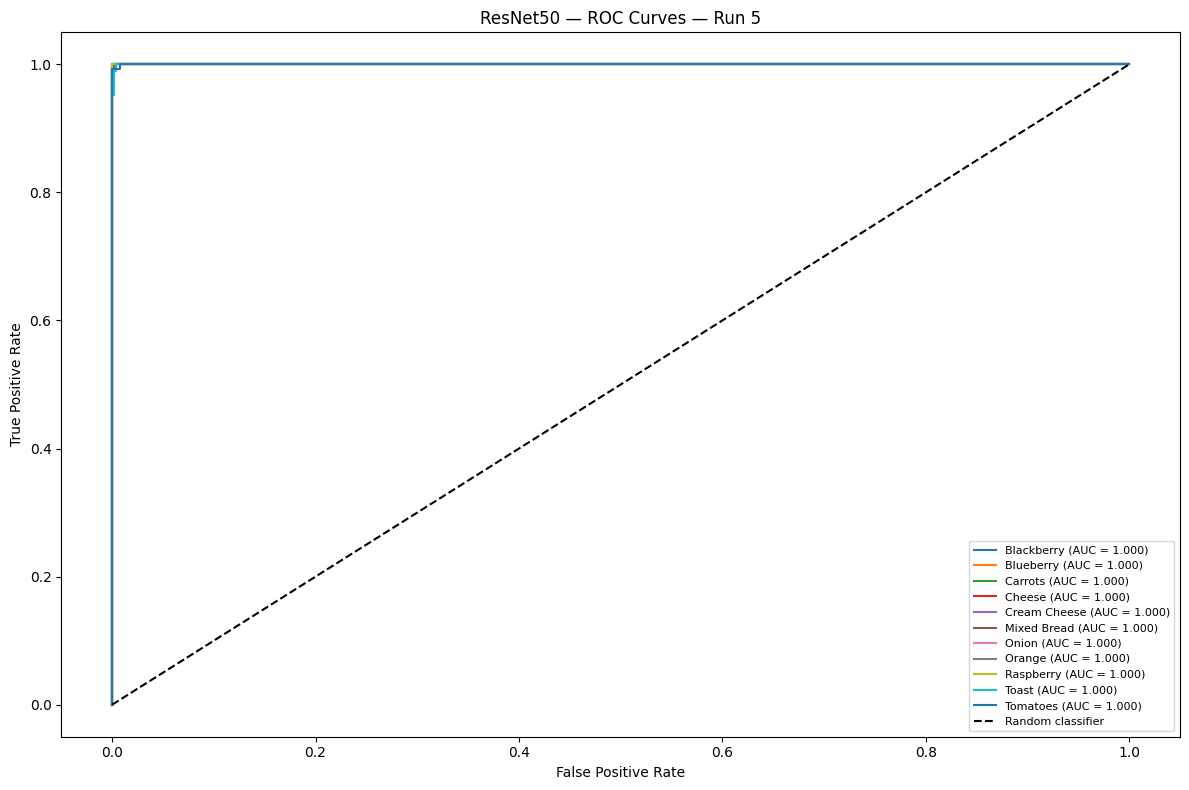

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_roc_curves_run5.png


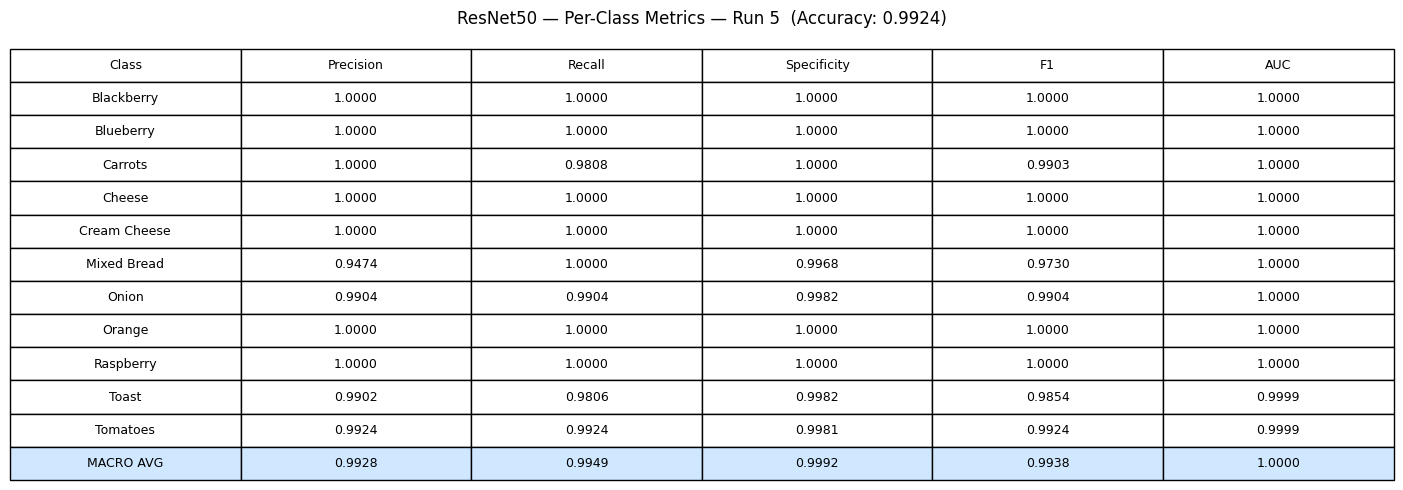

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_metrics_table_run5.png


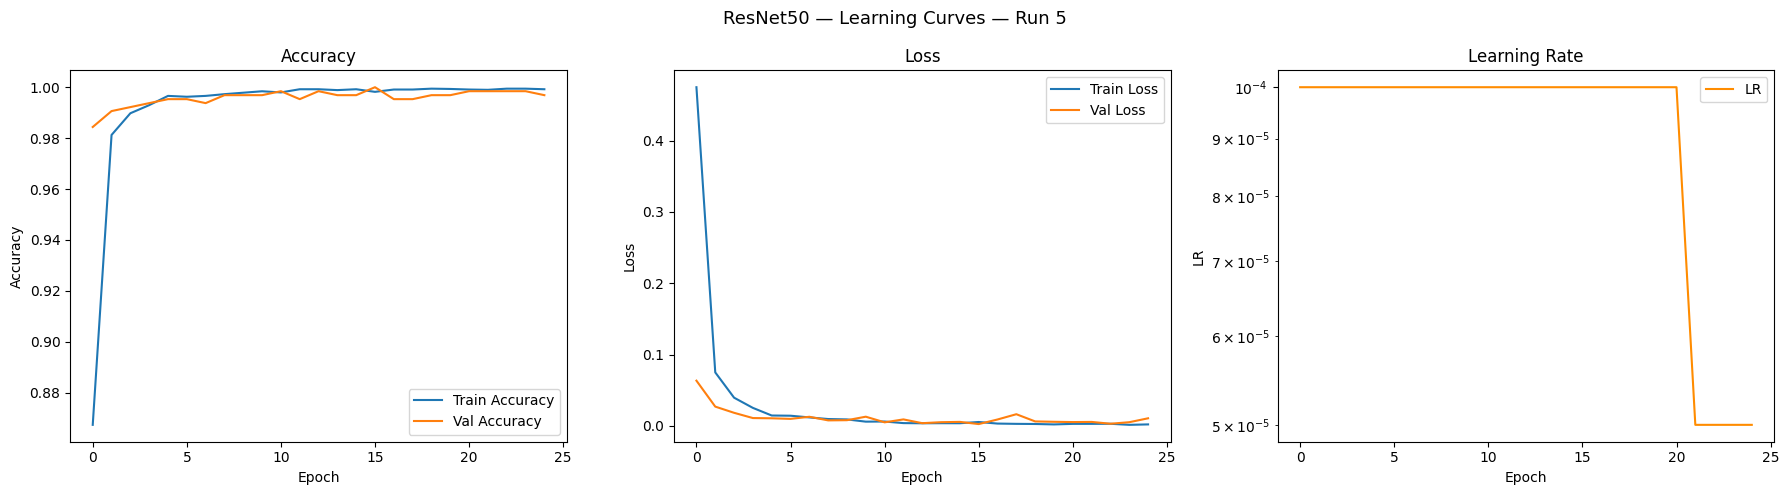

  Saved: D:\Mold Studies\Models\plots\resnet50\resnet50_learning_curves_run5.png

  STATISTICAL SUMMARY — ResNet50 — All 5 Runs
  Accuracy      : mean=0.9933  std=0.0012  min=0.9924  max=0.9954
  Precision     : mean=0.9943  std=0.0024  min=0.9915  max=0.9976
  Recall        : mean=0.9950  std=0.0009  min=0.9942  max=0.9967
  Specificity   : mean=0.9993  std=0.0001  min=0.9992  max=0.9995
  F1 Score      : mean=0.9946  std=0.0015  min=0.9929  max=0.9971
  AUC           : mean=1.0000  std=0.0000  min=1.0000  max=1.0000

  Best run     : Run 1
  Accuracy     : 0.9954
  F1 Score     : 0.9971
  Mean AUC     : 1.0000

  All plots saved to : D:\Mold Studies\Models\plots\resnet50

  ✓ Fragment 4 complete.
     resnet50_all_metrics and resnet50_all_run_results
     are ready for Fragment 5 — Model Comparison.



In [5]:
"""
Fragment 4 — Evaluation & Metrics
===================================
ResNet50 Mould/Fruit Multiclass Classification Pipeline

Evaluates all 5 trained runs against the test set.
Metrics computed per run and averaged across all runs:
    - Confusion Matrix
    - Accuracy
    - Precision
    - Recall
    - Specificity
    - F1 Score
    - ROC / AUC (one-vs-rest per class)
    - Learning Rate Curve

TEST DATA — loaded fresh here, never seen during training.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies\Mould Studies Multiclass"
TEST_DIR   = os.path.join(DATA_DIR, "test")
SAVE_DIR   = r"D:\Mold Studies\Models"
PLOT_DIR   = os.path.join(SAVE_DIR, "plots", "resnet50")

os.makedirs(PLOT_DIR, exist_ok=True)

# ── Step 1: Load Test Generator ───────────────────────────────────────────────
# ResNet50 requires preprocess_input not simple rescale
# Must match the preprocessing used in Fragment 1

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    shuffle     = False,        # must be False for correct label alignment
)

CLASS_NAMES = list(test_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("=" * 60)
print("  Step 1 — Test Generator Ready")
print("=" * 60)
print(f"  Architecture  : ResNet50")
print(f"  Preprocessing : preprocess_input")
print(f"  Test samples  : {test_generator.samples}")
print(f"  Classes       : {CLASS_NAMES}")
print(f"  Source        : {TEST_DIR}")
print("=" * 60)

# ── Step 2: Helper Functions ──────────────────────────────────────────────────

def compute_metrics(y_true, y_pred, y_prob):
    """
    Computes full evaluation metrics from predictions.
    Returns a dictionary of all metrics.
    """
    cm = confusion_matrix(y_true, y_pred)

    per_class = {}
    for i, cls in enumerate(CLASS_NAMES):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn

        precision   = tp / (tp + fp + 1e-7)
        recall      = tp / (tp + fn + 1e-7)
        specificity = tn / (tn + fp + 1e-7)
        f1          = 2 * precision * recall / (precision + recall + 1e-7)

        per_class[cls] = {
            "precision"  : precision,
            "recall"     : recall,
            "specificity": specificity,
            "f1"         : f1,
        }

    macro_precision   = np.mean([v["precision"]   for v in per_class.values()])
    macro_recall      = np.mean([v["recall"]      for v in per_class.values()])
    macro_specificity = np.mean([v["specificity"] for v in per_class.values()])
    macro_f1          = np.mean([v["f1"]          for v in per_class.values()])
    accuracy          = np.sum(y_true == y_pred) / len(y_true)

    # ROC / AUC — one-vs-rest per class
    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    roc_auc    = {}
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[cls] = {
            "fpr": fpr,
            "tpr": tpr,
            "auc": auc(fpr, tpr)
        }

    return {
        "cm"               : cm,
        "per_class"        : per_class,
        "accuracy"         : accuracy,
        "macro_precision"  : macro_precision,
        "macro_recall"     : macro_recall,
        "macro_specificity": macro_specificity,
        "macro_f1"         : macro_f1,
        "roc_auc"          : roc_auc,
    }


def plot_confusion_matrix(cm, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks      = np.arange(NUM_CLASSES),
        yticks      = np.arange(NUM_CLASSES),
        xticklabels = CLASS_NAMES,
        yticklabels = CLASS_NAMES,
        title       = f"ResNet50 — Confusion Matrix — Run {run_idx}",
        ylabel      = "True Label",
        xlabel      = "Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    thresh = cm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    path = os.path.join(save_dir, f"resnet50_confusion_matrix_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")


def plot_roc_curves(roc_auc, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 8))

    for cls in CLASS_NAMES:
        ax.plot(
            roc_auc[cls]["fpr"],
            roc_auc[cls]["tpr"],
            label=f"{cls} (AUC = {roc_auc[cls]['auc']:.3f})"
        )

    ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
    ax.set(
        title  = f"ResNet50 — ROC Curves — Run {run_idx}",
        xlabel = "False Positive Rate",
        ylabel = "True Positive Rate",
    )
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    path = os.path.join(save_dir, f"resnet50_roc_curves_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")


def plot_metrics_table(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.axis("off")

    rows = []
    for cls in CLASS_NAMES:
        pc = metrics["per_class"][cls]
        rows.append([
            cls,
            f"{pc['precision']:.4f}",
            f"{pc['recall']:.4f}",
            f"{pc['specificity']:.4f}",
            f"{pc['f1']:.4f}",
            f"{metrics['roc_auc'][cls]['auc']:.4f}",
        ])

    rows.append([
        "MACRO AVG",
        f"{metrics['macro_precision']:.4f}",
        f"{metrics['macro_recall']:.4f}",
        f"{metrics['macro_specificity']:.4f}",
        f"{metrics['macro_f1']:.4f}",
        f"{np.mean([metrics['roc_auc'][c]['auc'] for c in CLASS_NAMES]):.4f}",
    ])

    col_labels = ["Class", "Precision", "Recall",
                  "Specificity", "F1", "AUC"]

    table = ax.table(
        cellText  = rows,
        colLabels = col_labels,
        loc       = "center",
        cellLoc   = "center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.8)

    for j in range(len(col_labels)):
        table[len(rows), j].set_facecolor("#d0e8ff")

    ax.set_title(
        f"ResNet50 — Per-Class Metrics — Run {run_idx}  "
        f"(Accuracy: {metrics['accuracy']:.4f})",
        fontsize=12, pad=20
    )

    plt.tight_layout()
    path = os.path.join(save_dir, f"resnet50_metrics_table_run{run_idx}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path}")


def plot_learning_curves(csv_path, run_idx, save_dir):
    import pandas as pd

    if not os.path.exists(csv_path):
        print(f"  ⚠️  CSV log not found for Run {run_idx}: {csv_path}")
        return

    log = pd.read_csv(csv_path)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"ResNet50 — Learning Curves — Run {run_idx}", fontsize=13)

    # Accuracy
    axes[0].plot(log["epoch"], log["accuracy"],     label="Train Accuracy")
    axes[0].plot(log["epoch"], log["val_accuracy"], label="Val Accuracy")
    axes[0].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[0].legend()

    # Loss
    axes[1].plot(log["epoch"], log["loss"],     label="Train Loss")
    axes[1].plot(log["epoch"], log["val_loss"], label="Val Loss")
    axes[1].set(title="Loss", xlabel="Epoch", ylabel="Loss")
    axes[1].legend()

    # Learning Rate
    if "lr" in log.columns:
        axes[2].plot(log["epoch"], log["lr"],
                     color="darkorange", label="LR")
        axes[2].set(title="Learning Rate", xlabel="Epoch", ylabel="LR")
        axes[2].set_yscale("log")
        axes[2].legend()
    else:
        axes[2].text(0.5, 0.5, "LR not logged",
                     ha="center", va="center",
                     transform=axes[2].transAxes)
        axes[2].set_title("Learning Rate")

    plt.tight_layout()
    path = os.path.join(save_dir, f"resnet50_learning_curves_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")

# ── Step 3: Evaluate All 5 Runs ───────────────────────────────────────────────

all_metrics = []

for r in all_run_results:
    run_idx  = r["run"]
    ckpt     = os.path.join(SAVE_DIR, r["checkpoint"])
    csv_path = os.path.join(SAVE_DIR, f"resnet50_run{run_idx}_log.csv")

    print(f"\n{'='*60}")
    print(f"  Evaluating ResNet50 Run {run_idx} / {TOTAL_RUNS}")
    print(f"  Checkpoint : {ckpt}")
    print(f"{'='*60}")

    # Load model
    run_model = tf.keras.models.load_model(ckpt)

    # Reset generator — must be done before every predict
    test_generator.reset()

    # Predict
    y_prob = run_model.predict(
        test_generator,
        steps   = np.ceil(test_generator.samples / BATCH_SIZE),
        verbose = 1,
    )
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_generator.classes

    # Compute metrics
    metrics        = compute_metrics(y_true, y_pred, y_prob)
    metrics["run"] = run_idx
    all_metrics.append(metrics)

    # Print run summary
    print(f"\n  Architecture : ResNet50")
    print(f"  Run          : {run_idx}")
    print(f"  Accuracy     : {metrics['accuracy']:.4f}")
    print(f"  Precision    : {metrics['macro_precision']:.4f}")
    print(f"  Recall       : {metrics['macro_recall']:.4f}")
    print(f"  Specificity  : {metrics['macro_specificity']:.4f}")
    print(f"  F1 Score     : {metrics['macro_f1']:.4f}")
    print(f"  Mean AUC     : "
          f"{np.mean([metrics['roc_auc'][c]['auc'] for c in CLASS_NAMES]):.4f}")

    # Plots
    plot_confusion_matrix(metrics["cm"],    run_idx, PLOT_DIR)
    plot_roc_curves(metrics["roc_auc"],     run_idx, PLOT_DIR)
    plot_metrics_table(metrics,             run_idx, PLOT_DIR)
    plot_learning_curves(csv_path,          run_idx, PLOT_DIR)

# ── Step 4: Statistical Summary Across All 5 Runs ────────────────────────────

print(f"\n{'='*60}")
print(f"  STATISTICAL SUMMARY — ResNet50 — All {TOTAL_RUNS} Runs")
print(f"{'='*60}")

metric_keys = {
    "Accuracy"   : "accuracy",
    "Precision"  : "macro_precision",
    "Recall"     : "macro_recall",
    "Specificity": "macro_specificity",
    "F1 Score"   : "macro_f1",
}

for label, key in metric_keys.items():
    vals = [m[key] for m in all_metrics]
    print(f"  {label:<14}: "
          f"mean={np.mean(vals):.4f}  "
          f"std={np.std(vals):.4f}  "
          f"min={np.min(vals):.4f}  "
          f"max={np.max(vals):.4f}")

mean_aucs = [
    np.mean([m["roc_auc"][c]["auc"] for c in CLASS_NAMES])
    for m in all_metrics
]
print(f"  {'AUC':<14}: "
      f"mean={np.mean(mean_aucs):.4f}  "
      f"std={np.std(mean_aucs):.4f}  "
      f"min={np.min(mean_aucs):.4f}  "
      f"max={np.max(mean_aucs):.4f}")

print(f"{'='*60}")

# ── Step 5: Best Run ──────────────────────────────────────────────────────────

best_metrics = max(all_metrics, key=lambda x: x["accuracy"])
print(f"\n  Best run     : Run {best_metrics['run']}")
print(f"  Accuracy     : {best_metrics['accuracy']:.4f}")
print(f"  F1 Score     : {best_metrics['macro_f1']:.4f}")
print(f"  Mean AUC     : "
      f"{np.mean([best_metrics['roc_auc'][c]['auc'] for c in CLASS_NAMES]):.4f}")

# ── Step 6: Expose for cross-model comparison ─────────────────────────────────

resnet50_all_metrics     = all_metrics
resnet50_all_run_results = all_run_results

print(f"\n  All plots saved to : {PLOT_DIR}")
print(f"\n  ✓ Fragment 4 complete.")
print(f"     resnet50_all_metrics and resnet50_all_run_results")
print(f"     are ready for Fragment 5 — Model Comparison.\n")

In [6]:
"""
Per-Run Results Table — ResNet50
=====================================
Prints best training accuracy, best validation accuracy per run,
and full test metrics per run in a single consolidated table.
"""

import numpy as np
import pandas as pd

# ── Step 1: Collect per-run training history metrics ─────────────────────────
# Training accuracy is read from the CSV logs saved during training

train_accs = {}

for r in all_run_results:
    run_idx  = r["run"]
    csv_path = os.path.join(SAVE_DIR, f"resnet50_run{run_idx}_log.csv")

    if os.path.exists(csv_path):
        log = pd.read_csv(csv_path)
        train_accs[run_idx] = max(log["accuracy"])
    else:
        # Run 1 log is named differently
        csv_run1 = os.path.join(SAVE_DIR, "resnet50_training_log.csv")
        if os.path.exists(csv_run1):
            log = pd.read_csv(csv_run1)
            train_accs[run_idx] = max(log["accuracy"])
        else:
            train_accs[run_idx] = float("nan")

# ── Step 2: Build table rows ──────────────────────────────────────────────────

col_run   = 6
col_train = 12
col_val   = 12
col_test  = 12
col_prec  = 12
col_sens  = 12
col_f1    = 10
col_auc   = 10

divider = "=" * (col_run + col_train + col_val + col_test +
                 col_prec + col_sens + col_f1 + col_auc + 9)
thin    = "─" * (col_run + col_train + col_val + col_test +
                 col_prec + col_sens + col_f1 + col_auc + 9)

print(divider)
print("  PER-RUN RESULTS — ResNet50")
print(divider)
print(
    f"  {'Run':<{col_run}}"
    f"{'Train Acc':>{col_train}}"
    f"{'Val Acc':>{col_val}}"
    f"{'Test Acc':>{col_test}}"
    f"{'Precision':>{col_prec}}"
    f"{'Sensitivity':>{col_sens}}"
    f"{'F1 Score':>{col_f1}}"
    f"{'AUC':>{col_auc}}"
)
print(thin)

# ── Per-run rows ──────────────────────────────────────────────────────────────

for r, m in zip(all_run_results, all_metrics):
    run_idx     = r["run"]
    train_acc   = train_accs.get(run_idx, float("nan"))
    val_acc     = r["best_val_acc"]
    test_acc    = m["accuracy"]
    precision   = m["macro_precision"]
    sensitivity = m["macro_recall"]     # sensitivity = recall
    f1          = m["macro_f1"]
    mean_auc    = np.mean([m["roc_auc"][c]["auc"] for c in CLASS_NAMES])

    print(
        f"  {run_idx:<{col_run}}"
        f"{train_acc:>{col_train}.4f}"
        f"{val_acc:>{col_val}.4f}"
        f"{test_acc:>{col_test}.4f}"
        f"{precision:>{col_prec}.4f}"
        f"{sensitivity:>{col_sens}.4f}"
        f"{f1:>{col_f1}.4f}"
        f"{mean_auc:>{col_auc}.4f}"
    )

print(thin)

# ── Step 3: Statistical Summary ───────────────────────────────────────────────

train_vals = [train_accs[r["run"]] for r in all_run_results]
val_vals   = [r["best_val_acc"]    for r in all_run_results]
test_vals  = [m["accuracy"]        for m in all_metrics]
prec_vals  = [m["macro_precision"] for m in all_metrics]
sens_vals  = [m["macro_recall"]    for m in all_metrics]
f1_vals    = [m["macro_f1"]        for m in all_metrics]
auc_vals   = [
    np.mean([m["roc_auc"][c]["auc"] for c in CLASS_NAMES])
    for m in all_metrics
]

print(f"\n  {'─'*30}  Statistical Summary  {'─'*30}")
print(
    f"  {'Metric':<{col_run+4}}"
    f"{'Mean':>{col_train}}"
    f"{'Std':>{col_val}}"
    f"{'Min':>{col_test}}"
    f"{'Max':>{col_prec}}"
)
print(thin)

stat_metrics = {
    "Train Acc"  : train_vals,
    "Val Acc"    : val_vals,
    "Test Acc"   : test_vals,
    "Precision"  : prec_vals,
    "Sensitivity": sens_vals,
    "F1 Score"   : f1_vals,
    "AUC"        : auc_vals,
}

for label, vals in stat_metrics.items():
    clean_vals = [v for v in vals if not np.isnan(v)]
    print(
        f"  {label:<{col_run+4}}"
        f"{np.mean(clean_vals):>{col_train}.4f}"
        f"{np.std(clean_vals):>{col_val}.4f}"
        f"{np.min(clean_vals):>{col_test}.4f}"
        f"{np.max(clean_vals):>{col_prec}.4f}"
    )

print(divider)
print(f"\n  ✓ Summary table complete.")
print(f"     resnet50_all_metrics ready for Fragment 5 — Model Comparison.\n")

  PER-RUN RESULTS — ResNet50
  Run      Train Acc     Val Acc    Test Acc   Precision Sensitivity  F1 Score       AUC
───────────────────────────────────────────────────────────────────────────────────────────────
  1           0.9995      1.0000      0.9954      0.9976      0.9967    0.9971    1.0000
  2           0.9997      1.0000      0.9939      0.9967      0.9942    0.9954    1.0000
  3           0.9995      0.9984      0.9924      0.9928      0.9949    0.9938    1.0000
  4           0.9997      1.0000      0.9924      0.9915      0.9943    0.9929    1.0000
  5           0.9994      1.0000      0.9924      0.9928      0.9949    0.9938    1.0000
───────────────────────────────────────────────────────────────────────────────────────────────

  ──────────────────────────────  Statistical Summary  ──────────────────────────────
  Metric            Mean         Std         Min         Max
───────────────────────────────────────────────────────────────────────────────────────────────
 